In [1]:
!pip install duckdb
!pip install tabulate

In [2]:
import pandas as pd
import duckdb
from datetime import datetime
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'iframe_connected' #桑基图显示

from collections import defaultdict
from itertools import groupby

In [3]:
import matplotlib as mpl
# 设置全局默认图像大小、背景色等
mpl.rcParams['figure.figsize'] = (10, 6)
mpl.rcParams['figure.dpi'] = 120
mpl.rcParams['figure.facecolor'] = '#f0f4f8'  # 全局背景色
mpl.rcParams['axes.facecolor'] = '#f0f4f8'    # 坐标区域背景色
# mpl.rcParams['font.sans-serif'] = ['SimHei']  # 中文字体

In [4]:
#安装kaggle上能用的中文字体
!wget -q https://github.com/adobe-fonts/source-han-sans/raw/release/OTF/SimplifiedChinese/SourceHanSansSC-Regular.otf
import matplotlib.font_manager as fm
font_path = "SourceHanSansSC-Regular.otf"
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()

## 数据前处理 Data preprocessing

In [5]:
conn = duckdb.connect("taobao.duckdb")

导入数据库，同时将行为编码，将timestamp转化为datetime

In [6]:
conn.execute("""
    CREATE OR REPLACE TABLE origin_taobao_behavior AS
    SELECT 
        column0 AS uid,
        column1 AS pid,
        column2 AS cat_id,
        CASE 
            WHEN column3 = 'pv' THEN 0
            WHEN column3 = 'fav' THEN 1
            WHEN column3 = 'cart' THEN 2
            WHEN column3 = 'buy' THEN 3
        ELSE NULL
        END AS behavior,
        to_timestamp(column4) + INTERVAL 8 HOUR AS datetime 
    FROM read_csv_auto('/kaggle/input/taobao-user-behavior/UserBehavior.csv')
""")
# 在本地编辑要注意UTC时间和当地时间的转换

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [7]:
result = conn.execute("SELECT * FROM origin_taobao_behavior LIMIT 5").fetchdf()
result

,uid,pid,cat_id,behavior,datetime
0,1,2268318,2520377,0,2017-11-25 01:21:10+00:00
1,1,2333346,2520771,0,2017-11-25 06:15:33+00:00
2,1,2576651,149192,0,2017-11-25 09:21:25+00:00
3,1,3830808,4181361,0,2017-11-25 15:04:53+00:00
4,1,4365585,2520377,0,2017-11-25 15:49:06+00:00


将datetime分解成年月日小时

In [8]:
conn.execute("""
    CREATE OR REPLACE TABLE origin_taobao_behavior AS
    SELECT 
        *,
        EXTRACT(year FROM datetime) AS year,
        EXTRACT(month FROM datetime) AS month,
        EXTRACT(day FROM datetime) AS day,
        EXTRACT(hour FROM datetime) AS hour,
        CAST(datetime AS DATE) AS date 
    FROM origin_taobao_behavior
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

提取2017年11月25日至2017年12月3日的数据，去重后保存为表taobao_behavior，后续的分析均基于此表

In [9]:
conn.execute("""
    CREATE OR REPLACE TABLE taobao_behavior AS
    SELECT DISTINCT *
    FROM origin_taobao_behavior
    WHERE (datetime >= '2017-11-25') AND (datetime < '2017-12-04')
""")
#注意此处的时间筛选条件，用between and的时候sql似乎会将23:59:59的数据近似归入下一天，最好不要采用

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [10]:
result = conn.execute("SELECT * FROM taobao_behavior LIMIT 5").fetchdf()
result

,uid,pid,cat_id,behavior,datetime,year,month,day,hour,date
0,1015181,4549688,2885642,0,2017-11-25 10:54:01+00:00,2017,11,25,10,2017-11-25
1,1015184,2129139,982926,0,2017-12-01 16:28:23+00:00,2017,12,1,16,2017-12-01
2,1015184,2792447,982926,0,2017-12-03 15:03:18+00:00,2017,12,3,15,2017-12-03
3,1015193,1860532,1488813,0,2017-11-30 21:57:30+00:00,2017,11,30,21,2017-11-30
4,1015219,4953050,323851,0,2017-11-25 20:35:03+00:00,2017,11,25,20,2017-11-25


In [11]:
#数据总行数cnt
cnt = conn.execute("SELECT count(*) FROM taobao_behavior ").fetchone()
print('总行数：',cnt[0])

#缺失值
df_null_cnt = conn.execute("""
    SELECT
        SUM(uid IS NULL) AS id_nullcnt,
        SUM(pid IS NULL) AS pid_nullcnt,
        SUM(cat_id IS NULL) AS cat_nullcnt,
        SUM(behavior IS NULL) AS bh_nullcnt,
        SUM(datetime IS NULL) AS dt_nullcnt
    FROM taobao_behavior 
    """).fetchdf()
print('缺失情况：')
print(tabulate(df_null_cnt, headers='keys', tablefmt='psql'))

总行数： 100095182
缺失情况：
+----+--------------+---------------+---------------+--------------+--------------+
|    |   id_nullcnt |   pid_nullcnt |   cat_nullcnt |   bh_nullcnt |   dt_nullcnt |
|----+--------------+---------------+---------------+--------------+--------------|
|  0 |            0 |             0 |             0 |            0 |            0 |
+----+--------------+---------------+---------------+--------------+--------------+


## 用户流量指标分析

活跃用户定义：每天pv>3或者有fav、cart、buy动作的用户。

In [12]:
conn.execute("""
    CREATE OR REPLACE VIEW view_bh_gp_date AS
    SELECT
        date,uid,
        SUM(behavior = 0) AS pv_cnt,
        SUM(behavior = 1) AS fav_cnt,
        SUM(behavior = 2) AS cart_cnt,
        SUM(behavior = 3) AS buy_cnt
    FROM taobao_behavior 
    GROUP BY date,uid
    ORDER BY 1,2
    """)
df_gp_date = conn.execute("""
    SELECT
        date,
        COUNT(DISTINCT uid) AS uv,    --每日uv
        SUM((pv_cnt > 3) OR (NOT (fav_cnt = 0 AND cart_cnt = 0 AND buy_cnt = 0))) AS active_users,  --每日活跃用户数
        SUM(pv_cnt) AS pv,  --每日pv
        SUM(fav_cnt) AS fav, --每日收藏数
        SUM(fav_cnt != 0) AS fav_users,  --每日收藏用户数 
        SUM(cart_cnt) AS cart, --每日添加购物车数
        SUM(cart_cnt != 0) AS cart_users,  --每日添加购物车用户数   
        SUM(buy_cnt) AS buy, --每日购买数
        SUM(buy_cnt != 0) AS buy_users, --每日购买用户数
        SUM(pv_cnt = 1 AND fav_cnt = 0 AND cart_cnt = 0 AND buy_cnt = 0)  AS one_pv_users,  --每日仅有1次pv的用户数
        SUM(fav_cnt + cart_cnt) / SUM(pv_cnt) AS funnel_1, --第一层漏斗
        SUM(buy_cnt) / SUM(fav_cnt + cart_cnt) AS funnel_2, --第一层漏斗
    FROM view_bh_gp_date
    GROUP BY date
    ORDER BY 1
    """).fetchdf()
df_gp_date

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,date,uv,active_users,pv,fav,fav_users,cart,cart_users,buy,buy_users,one_pv_users,funnel_1,funnel_2
0,2017-11-25,706641,550930.0,9353416.0,302071.0,115031.0,563376.0,237553.0,201144.0,132622.0,77201.0,0.092527,0.232416
1,2017-11-26,715516,563536.0,9567422.0,308954.0,117699.0,582581.0,247038.0,205638.0,136048.0,73765.0,0.093184,0.230656
2,2017-11-27,710094,556784.0,9041186.0,291221.0,114396.0,541904.0,235841.0,226834.0,146934.0,74719.0,0.092148,0.272269
3,2017-11-28,709257,554549.0,8842932.0,289100.0,114014.0,534157.0,234424.0,211997.0,139845.0,74924.0,0.093098,0.257510
4,2017-11-29,718922,565636.0,9210820.0,298587.0,116526.0,551593.0,240008.0,223068.0,146220.0,73976.0,0.092302,0.262377
5,2017-11-30,730597,574986.0,9358998.0,302264.0,117689.0,565015.0,244083.0,221459.0,146128.0,73438.0,0.092668,0.255349
6,2017-12-01,740139,585756.0,9718956.0,307115.0,119619.0,623346.0,261298.0,210010.0,139971.0,74065.0,0.095737,0.225705
7,2017-12-02,970401,752474.0,12329641.0,396749.0,151183.0,793569.0,332526.0,257903.0,174487.0,105513.0,0.096541,0.216667
8,2017-12-03,966977,744884.0,12237300.0,392197.0,149962.0,774905.0,327795.0,257754.0,173225.0,109487.0,0.095373,0.220850


In [13]:
def ini_plt_style(xlabel,ylabel,title):
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()

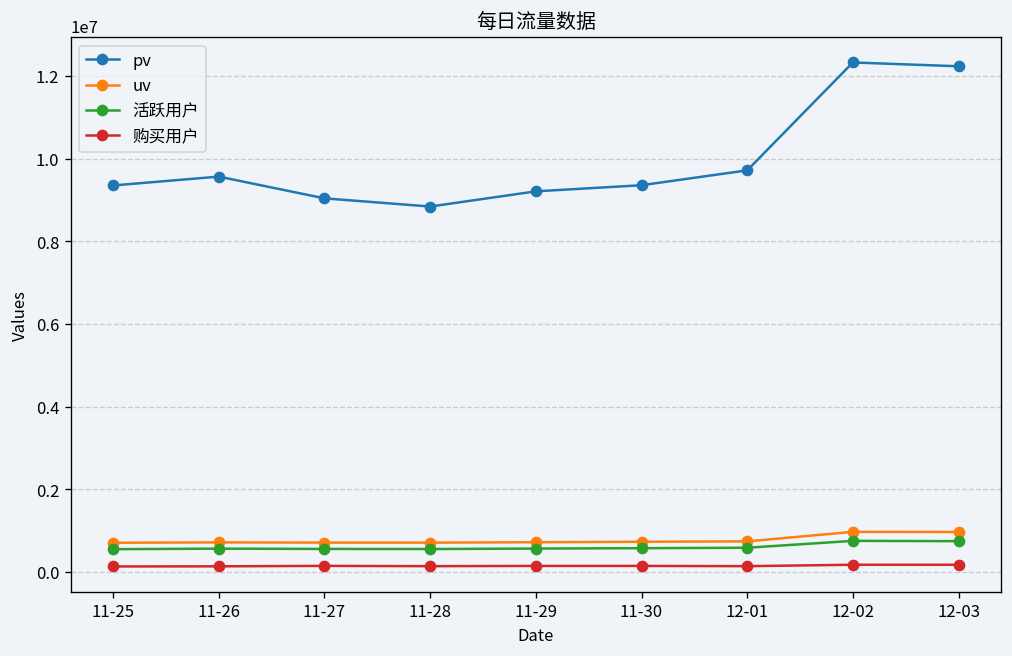

In [14]:
for col, label in zip(
    ['pv', 'uv', 'active_users', 'buy_users'],
    ['pv', 'uv', '活跃用户', '购买用户']):
    plt.plot(df_gp_date['date'].dt.strftime('%m-%d'), df_gp_date[col], label=label,marker='o' )
ini_plt_style('Date','Values','每日流量数据')

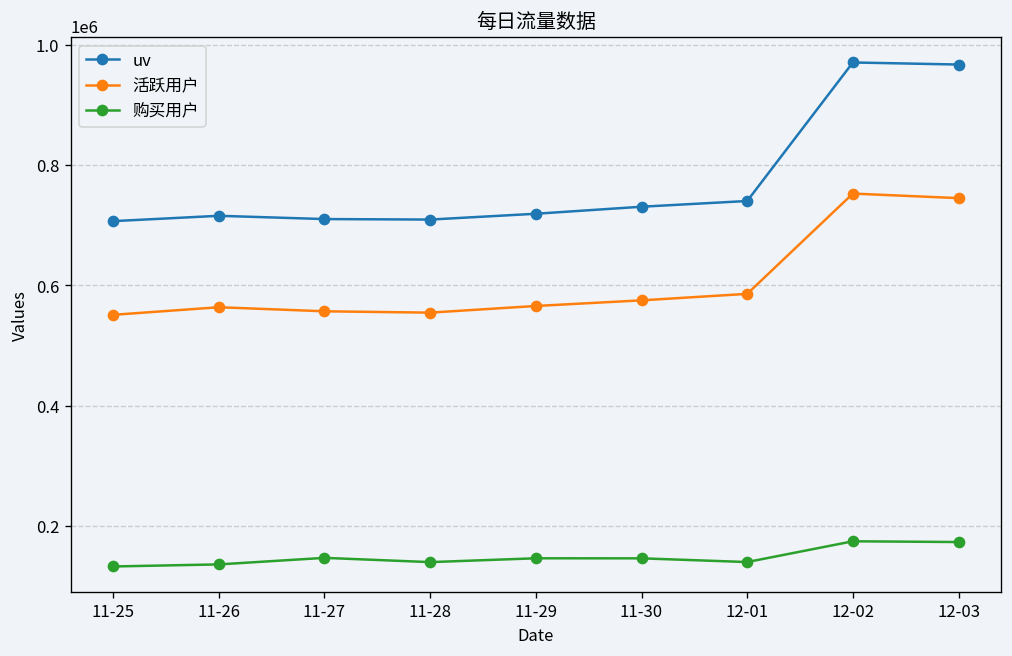

In [15]:
for col, label in zip(
    [ 'uv', 'active_users', 'buy_users'],
    [ 'uv', '活跃用户', '购买用户']):
    plt.plot(df_gp_date['date'].dt.strftime('%m-%d'), df_gp_date[col], label=label,marker='o' )
ini_plt_style('Date','Values','每日流量数据')

In [16]:
uprate = df_gp_date.loc[7:8,['pv', 'uv', 'active_users', 'buy_users']].mean() / df_gp_date.loc[0:6,['pv', 'uv', 'active_users', 'buy_users']].mean()-1

In [17]:
print(f'4项指标（pv、uv、活跃用户、支付用户）在12月2日、3日有明显涨幅,较前7日日均数据涨幅为：\
{uprate.iloc[0]:.1%},{uprate.iloc[1]:.1%},{uprate.iloc[2]:.1%},{uprate.iloc[3]:.1%}')

4项指标（pv、uv、活跃用户、支付用户）在12月2日、3日有明显涨幅,较前7日日均数据涨幅为：32.1%,34.8%,32.6%,23.2%


In [18]:
total_uid = conn.execute("""
    SELECT
        COUNT(DISTINCT uid)
    FROM taobao_behavior 
    """).fetchone()
#日均活跃率 = 日均活跃用户/总uv
df_gp_date['active_r'] = df_gp_date['active_users'] / total_uid[0]
df_gp_date[['date','active_r']]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,date,active_r
0,2017-11-25,0.557627
1,2017-11-26,0.570386
2,2017-11-27,0.563552
3,2017-11-28,0.561290
4,2017-11-29,0.572511
5,2017-11-30,0.581975
6,2017-12-01,0.592876
7,2017-12-02,0.761620
8,2017-12-03,0.753938


In [19]:
df_gp_date

,date,uv,active_users,pv,fav,fav_users,cart,cart_users,buy,buy_users,one_pv_users,funnel_1,funnel_2,active_r
0,2017-11-25,706641,550930.0,9353416.0,302071.0,115031.0,563376.0,237553.0,201144.0,132622.0,77201.0,0.092527,0.232416,0.557627
1,2017-11-26,715516,563536.0,9567422.0,308954.0,117699.0,582581.0,247038.0,205638.0,136048.0,73765.0,0.093184,0.230656,0.570386
2,2017-11-27,710094,556784.0,9041186.0,291221.0,114396.0,541904.0,235841.0,226834.0,146934.0,74719.0,0.092148,0.272269,0.563552
3,2017-11-28,709257,554549.0,8842932.0,289100.0,114014.0,534157.0,234424.0,211997.0,139845.0,74924.0,0.093098,0.257510,0.561290
4,2017-11-29,718922,565636.0,9210820.0,298587.0,116526.0,551593.0,240008.0,223068.0,146220.0,73976.0,0.092302,0.262377,0.572511
5,2017-11-30,730597,574986.0,9358998.0,302264.0,117689.0,565015.0,244083.0,221459.0,146128.0,73438.0,0.092668,0.255349,0.581975
6,2017-12-01,740139,585756.0,9718956.0,307115.0,119619.0,623346.0,261298.0,210010.0,139971.0,74065.0,0.095737,0.225705,0.592876
7,2017-12-02,970401,752474.0,12329641.0,396749.0,151183.0,793569.0,332526.0,257903.0,174487.0,105513.0,0.096541,0.216667,0.761620
8,2017-12-03,966977,744884.0,12237300.0,392197.0,149962.0,774905.0,327795.0,257754.0,173225.0,109487.0,0.095373,0.220850,0.753938


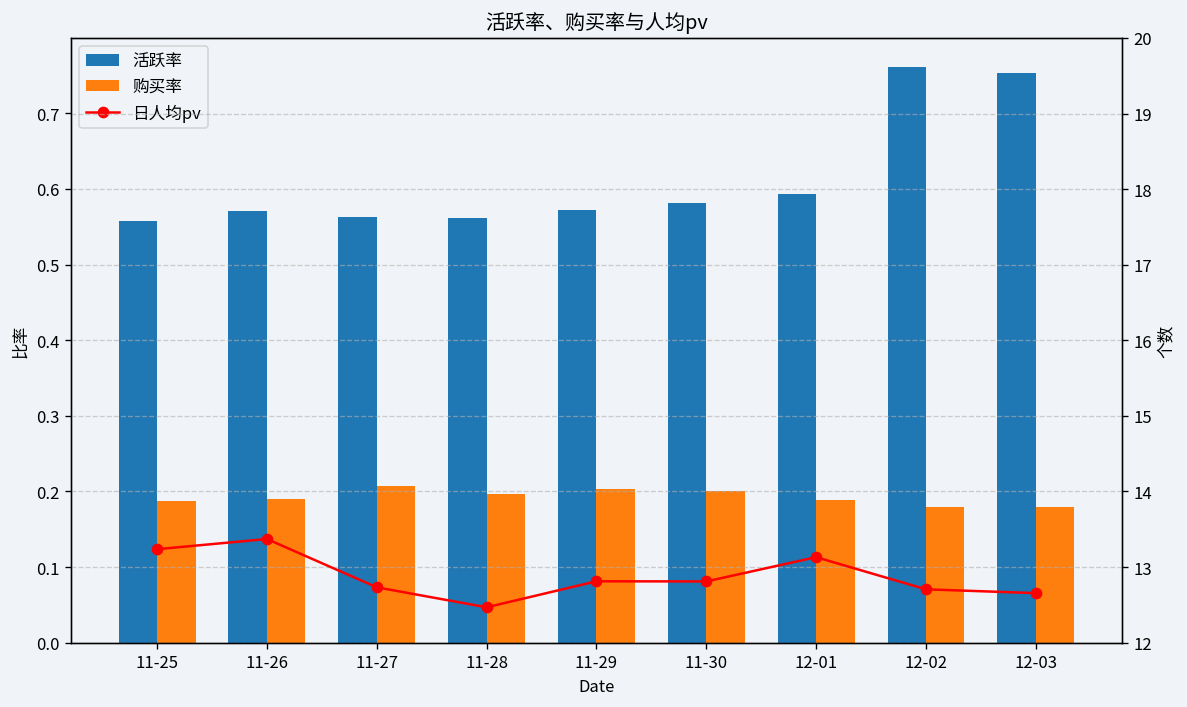

In [20]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
# 获取日期作为x轴标签
x_labels = df_gp_date['date'].dt.strftime('%m-%d')
x = np.arange(len(x_labels))  # 创建位置索引
width = 0.35  # 设置条形宽度

# 绘制活跃率
ax1.bar(x - width/2, df_gp_date['active_r'], width, label='活跃率')
# 绘制购买率
ax1.bar(x + width/2, df_gp_date['buy_users'] / df_gp_date['uv'], width, label='购买率')
# 绘制日人均pv折线图
ax2.plot(x, df_gp_date['pv'] / df_gp_date['uv'], label='日人均pv',color = 'red',marker = 'o')
ax2.set_ylim(12, 20) 

plt.xticks(x, x_labels)

ax1.set_xlabel('Date')
ax1.set_ylabel('比率')
ax1.tick_params(axis='y')

ax2.set_ylabel('个数')
ax2.tick_params(axis='y')

# 添加标题和图例
plt.title('活跃率、购买率与人均pv')
# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

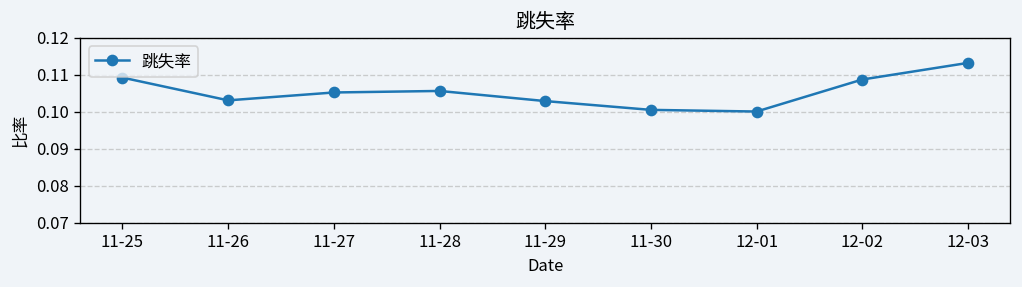

In [21]:
#跳失率
plt.figure(figsize=(10, 2)) 
plt.gca().set_ylim(0.07, 0.12) 
plt.plot(df_gp_date['date'].dt.strftime('%m-%d'), df_gp_date['one_pv_users'] / df_gp_date['uv'], label='跳失率',marker='o')
ini_plt_style('Date','比率','跳失率')

In [22]:
df_gp_date

,date,uv,active_users,pv,fav,fav_users,cart,cart_users,buy,buy_users,one_pv_users,funnel_1,funnel_2,active_r
0,2017-11-25,706641,550930.0,9353416.0,302071.0,115031.0,563376.0,237553.0,201144.0,132622.0,77201.0,0.092527,0.232416,0.557627
1,2017-11-26,715516,563536.0,9567422.0,308954.0,117699.0,582581.0,247038.0,205638.0,136048.0,73765.0,0.093184,0.230656,0.570386
2,2017-11-27,710094,556784.0,9041186.0,291221.0,114396.0,541904.0,235841.0,226834.0,146934.0,74719.0,0.092148,0.272269,0.563552
3,2017-11-28,709257,554549.0,8842932.0,289100.0,114014.0,534157.0,234424.0,211997.0,139845.0,74924.0,0.093098,0.257510,0.561290
4,2017-11-29,718922,565636.0,9210820.0,298587.0,116526.0,551593.0,240008.0,223068.0,146220.0,73976.0,0.092302,0.262377,0.572511
5,2017-11-30,730597,574986.0,9358998.0,302264.0,117689.0,565015.0,244083.0,221459.0,146128.0,73438.0,0.092668,0.255349,0.581975
6,2017-12-01,740139,585756.0,9718956.0,307115.0,119619.0,623346.0,261298.0,210010.0,139971.0,74065.0,0.095737,0.225705,0.592876
7,2017-12-02,970401,752474.0,12329641.0,396749.0,151183.0,793569.0,332526.0,257903.0,174487.0,105513.0,0.096541,0.216667,0.761620
8,2017-12-03,966977,744884.0,12237300.0,392197.0,149962.0,774905.0,327795.0,257754.0,173225.0,109487.0,0.095373,0.220850,0.753938


<Axes: title={'center': '相关系数'}>

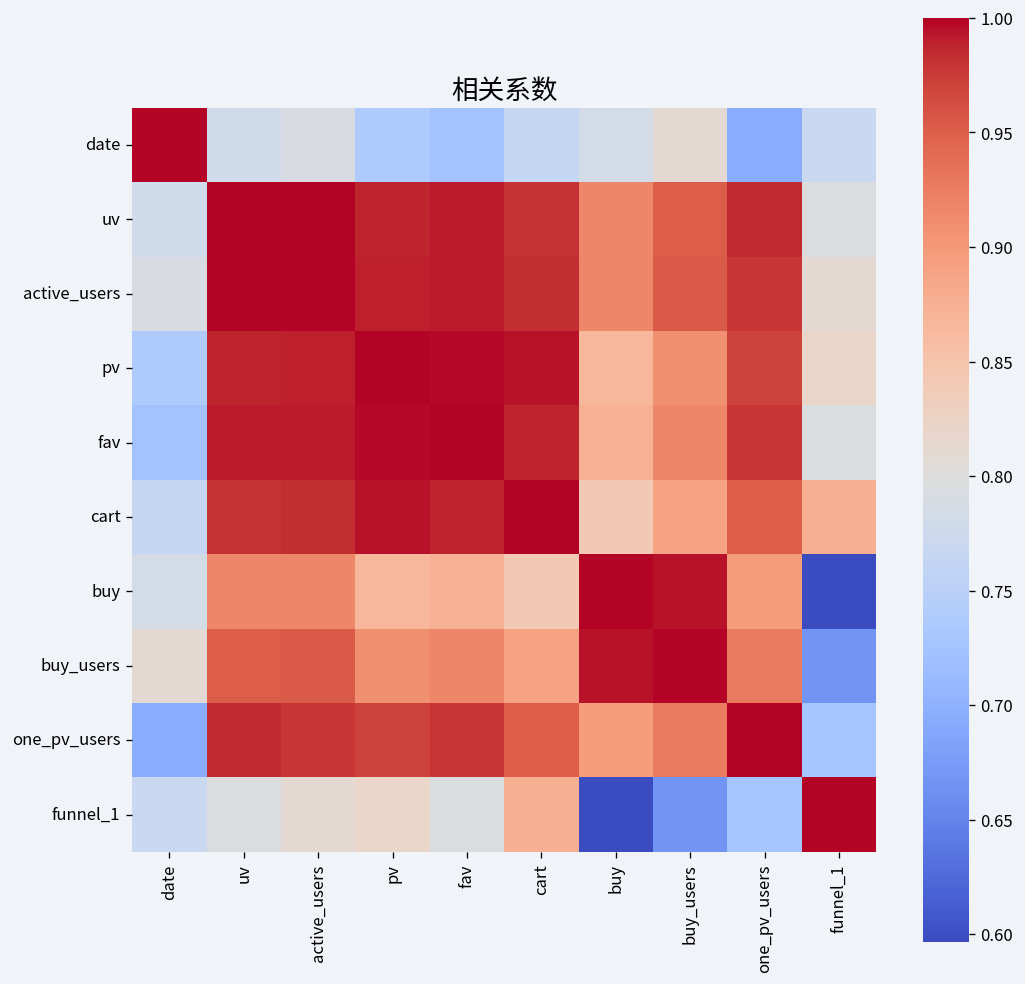

In [23]:
df_gp_date_corr = df_gp_date.iloc[:, [0,1,2,3,4,6,8,9,10,11]]
correlation = df_gp_date_corr.corr()
f , ax = plt.subplots(figsize = (10, 10))
plt.title('相关系数',y=1,size=16)
sns.heatmap(correlation,cmap='coolwarm',square = True)

小结：
- 可以看出双十二的预热活动给流量数据带来了显著增长，浏览类的数据增长了30%以上，购买数据增长了20%以上
- 从日均活跃率、购买率、日人均pv来看，活跃率在临近双十二的周末有较为明显的上涨，由60%不到上涨至75%左右，但是说明①双十二的活动仍有可扩大宣传，增加活跃用户的空间；②平日可以设置更多的浏览活动奖励。购买率在2、3日有一个小幅的降低，这可能是因为人们倾向于将购买行为后置到双十二当天，对此可以采取的方案有保价一个月、提前开启预售场。日人均pv在13左右波动，可以看出用户的人均浏览需求还是相对稳定的。
- 从跳失率看长期维持在10~11%上下，属于正常波动，反映了app有良好的用户忠诚度。
- 从相关性来看，购买量与买家数量、uv、活跃用户等指标相关性更高。

## 商品数据分析

In [24]:
totals = conn.execute("""
    SELECT
        COUNT(*) AS 行为总数,
        COUNT(DISTINCT uid) AS 总用户数,              
        COUNT(DISTINCT pid) AS 总商品数量,
        COUNT(DISTINCT cat_id) AS 商品大类数量,
        SUM(behavior = 0) AS 总pv,              
        SUM(behavior = 1) AS 总收藏量,
        SUM(behavior = 2) AS 总添加购物车量,            
        SUM(behavior = 3) AS 总销量
    FROM taobao_behavior 
    """).fetchdf()
totals

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,行为总数,总用户数,总商品数量,商品大类数量,总pv,总收藏量,总添加购物车量,总销量
0,100095182,987991,4161138,9437,89660671.0,2888258.0,5530446.0,2015807.0


按商品大类分析：

In [25]:
sql=f"""
    CREATE OR REPLACE VIEW view_gp_cat AS
    SELECT
        cat_id,
        SUM(behavior = 3) AS sales_v, --商品大类销量
        SUM(behavior = 3) / {totals.iloc[0,6]} AS sales_v_ratio, --商品大类销量占比
        COUNT(DISTINCT pid) AS products --商品数量
    FROM taobao_behavior 
    GROUP BY cat_id
    """
conn.execute(sql)
df_sold = conn.execute("""
    SELECT
        *
    FROM view_gp_cat 
    ORDER BY 2 DESC
    """).fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

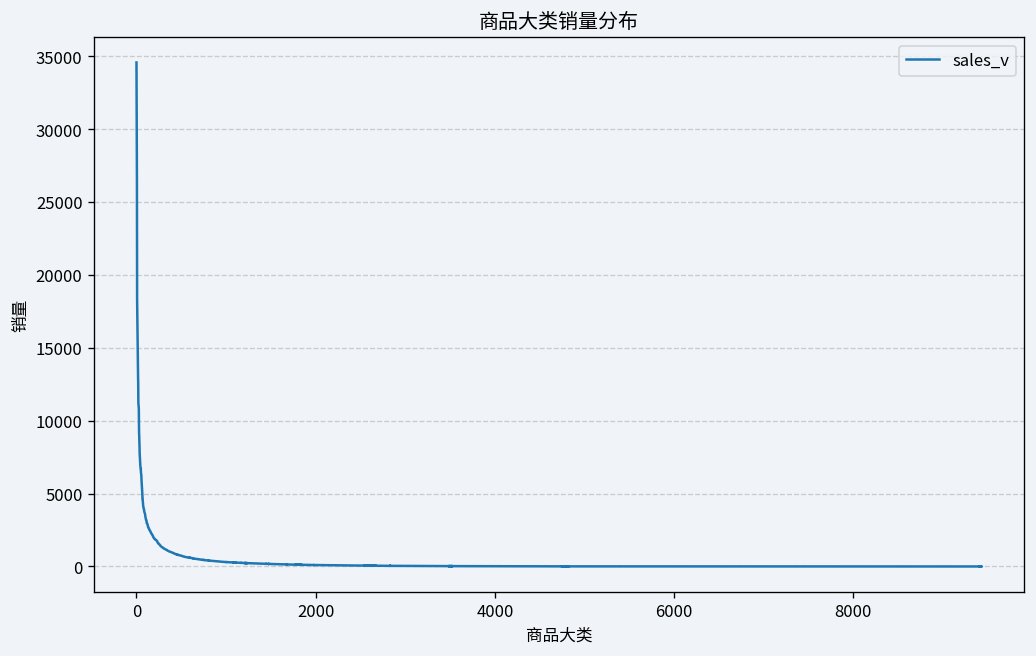

In [26]:
df_sold['sales_v'].sort_values().plot()
ini_plt_style('商品大类', '销量','商品大类销量分布')

可以看出商品大类的销量分布是一个非常明显的长尾分布，大多数购买集中在头部商品。

In [27]:
head_10_num = int(len(df_sold)*0.1)
df_sold.iloc[0:head_10_num]['sales_v_ratio'].sum()

0.31017263345487867

前10%的商品大类贡献了85%的销量。

类似的，从细分商品来看：

In [28]:
sql=f"""
    CREATE OR REPLACE VIEW view_gp_pid AS
    SELECT
        pid,
        SUM(behavior = 3) AS sales_v, --商品销量
        SUM(behavior = 3) / {totals.iloc[0,6]} AS sales_v_ratio, --商品销量占比
        SUM(behavior = 0) AS pv_v, --商品浏览量
        SUM(behavior IN (1, 2)) AS fav_cart_v, --商品收藏+添加购物车量
        IF(SUM(behavior = 0) = 0 ,NULL,SUM(behavior IN (1, 2)) / SUM(behavior = 0)) AS funnel_1, --漏斗1代表收藏加购量与pv的比率
        IF(SUM(behavior IN (1, 2)) = 0 ,NULL,SUM(behavior = 3) / SUM(behavior IN (1, 2))) AS funnel_2 --漏斗2代表购买量与收藏加购量的比率
    FROM taobao_behavior 
    GROUP BY pid
    """
conn.execute(sql)
df_sold_products = conn.execute("""
    SELECT
        *
    FROM view_gp_pid
    ORDER BY 2 DESC
    """).fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

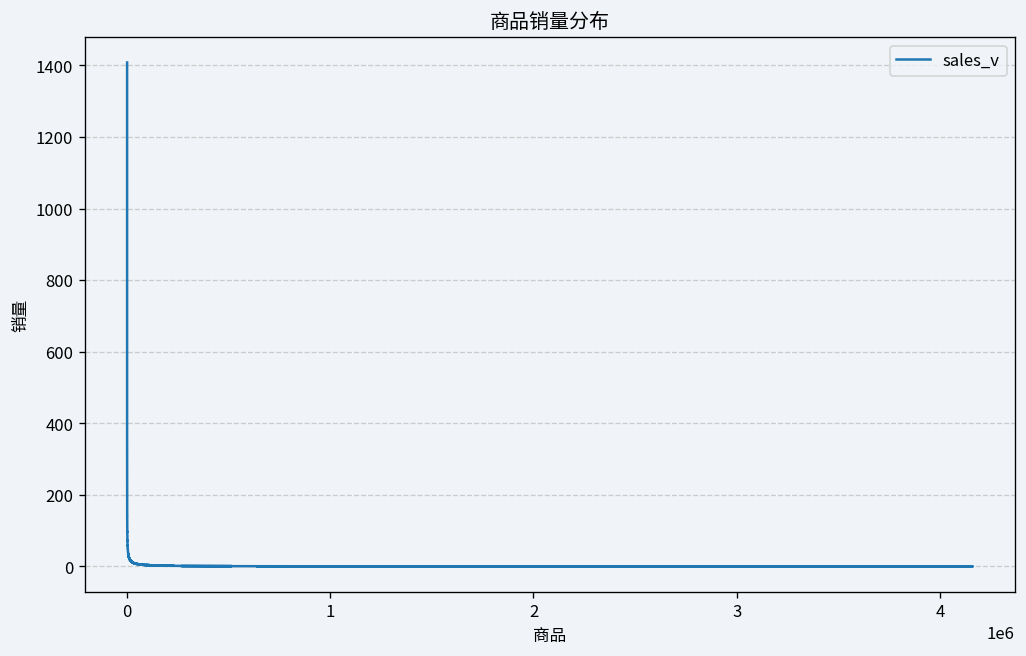

In [29]:
df_sold_products['sales_v'].sort_values().plot()
ini_plt_style('商品', '销量','商品销量分布')

In [30]:
head_10_pnum = int(len(df_sold_products)*0.1)
df_sold_products.iloc[0:head_10_pnum]['sales_v_ratio'].sum()

0.32419772293229154

从细分商品来看，销量集中在头部的效应更加明显，前10%的商品销量占据总销量的89%，也说明了平台商品可能存在赢家通吃，同质化消费的问题。

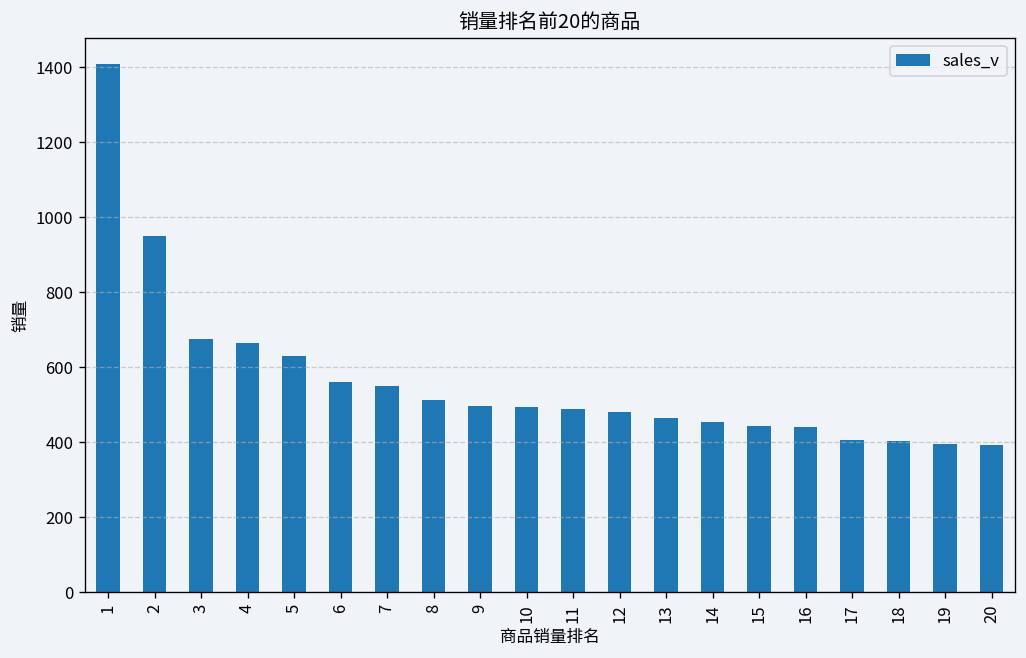

In [31]:
df_sold_products.iloc[0:20]['sales_v'].plot(kind = 'bar')
xticks = plt.xticks()[0]  # 获取刻度位置
plt.xticks(xticks, [int(x + 1) for x in xticks]) 
ini_plt_style('商品销量排名','销量','销量排名前20的商品')

In [32]:
df_sold_products.iloc[0:20]

,pid,sales_v,sales_v_ratio,pv_v,fav_cart_v,funnel_1,funnel_2
0,3122135,1408.0,0.000255,1779.0,494.0,0.277684,2.850202
1,3031354,950.0,0.000172,17169.0,2274.0,0.132448,0.417766
2,3964583,675.0,0.000122,5018.0,728.0,0.145078,0.927198
3,2560262,665.0,0.000120,10388.0,1580.0,0.152099,0.420886
4,2964774,629.0,0.000114,6579.0,853.0,0.129655,0.737397
5,740947,560.0,0.000101,7738.0,1285.0,0.166064,0.435798
6,1910706,548.0,0.000099,1645.0,217.0,0.131915,2.525346
7,1116492,512.0,0.000093,898.0,210.0,0.233853,2.438095
8,705557,497.0,0.000090,9308.0,1062.0,0.114095,0.467985
9,4443059,493.0,0.000089,14082.0,1285.0,0.091251,0.383658


In [33]:
df_sold_products['funnel_1'].describe()

count    4.067842e+06
mean     8.365723e-02
std      2.414645e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      9.090909e-02
max      2.140000e+02
Name: funnel_1, dtype: float64

In [34]:
df_sold_products['funnel_2'].describe()

count    1.532042e+06
mean     2.031366e-01
std      6.246023e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.000000e-01
max      2.440000e+02
Name: funnel_2, dtype: float64

从上图可以看出商品中出现了两款爆款商品pid为3122135，总销量1408；pid3031354，总销量950。从漏斗转化率来看，第一层漏斗即浏览量到收藏加购漏斗，商品平均转化率为8.37%，按总量计算为9.38%，相差不大，说明商品的曝光效果大致相同，从前20名销量商品的funnel_1上也能看出来。但是第二层漏斗即收藏加购到购买的漏斗，排名前20的商品中有不少funnel_2大于1的，说明他们在统计周期内的收藏加购量不高，但仍获取了高销量，其原因可能是这些商品在早期就已经采取了宣传措施，进行了促进消费者提前加购的活动，这也是它们能获得更大销量的原因之一。

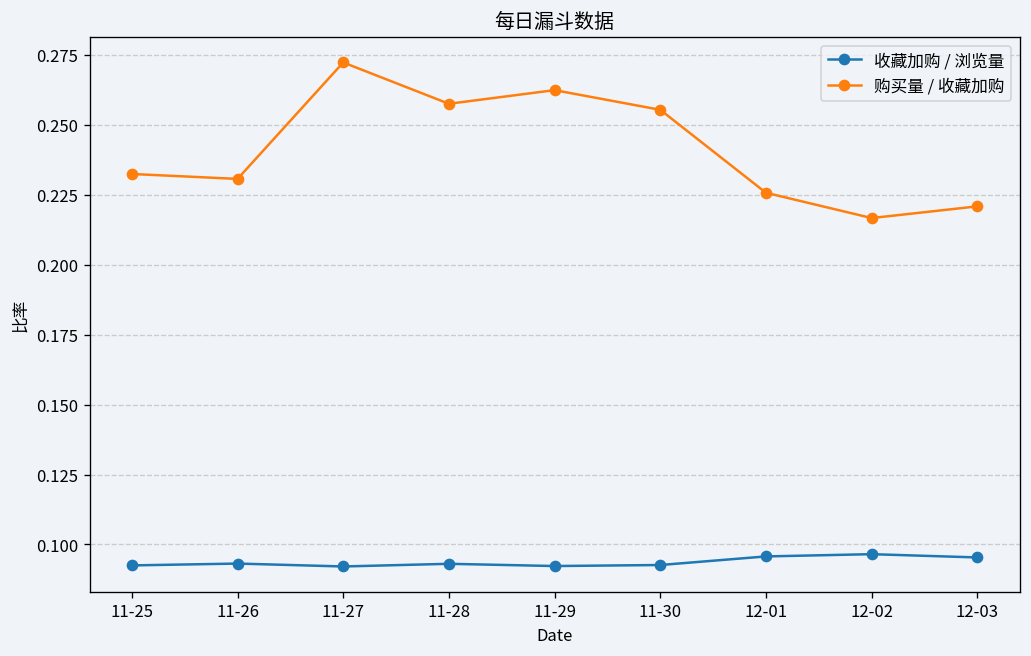

In [35]:
df_gp_date['funnel_2']
plt.plot(df_gp_date['date'].dt.strftime('%m-%d'), df_gp_date['funnel_1'] , label='收藏加购 / 浏览量',marker='o')
plt.plot(df_gp_date['date'].dt.strftime('%m-%d'), df_gp_date['funnel_2'] , label='购买量 / 收藏加购',marker='o')
ini_plt_style('Date','比率','每日漏斗数据')

小结：
- 无论从商品大类还是细分商品上来看，前10%的商品都贡献了将近9成的总销量。可以考虑将曝光资源更多向头部商品集中。
- 出现了两款爆款商品pid为3122135，总销量1408；pid3031354，总销量950，均遥遥领先其余商品，可以推荐二者的产品和宣传策略供商家们学习参考。
- 从商品的漏斗转化来看，曝光量对收藏加购和销售数据的影响不区分商品，销量更好的商品在自身的宣传策略上应有更多的可取之处。
- 平台呈现出同质化竞争加剧的情况，建议将商品门类更加细分，满足更多的小众需求，不要趋同化。

## 用户路径分析

针对单一用户单一商品的行为路径进行分析。

In [36]:
conn.execute("""
    CREATE OR REPLACE VIEW view_gp_uid AS
    SELECT
        uid,
        pid,
        count(*) AS cnt
    FROM taobao_behavior 
    GROUP BY uid,pid
    """)


In [37]:
df_gp_uid = conn.execute("""
    SELECT
        *
    FROM view_gp_uid 
    ORDER BY cnt DESC
    """).fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [38]:
trace_num = df_gp_uid['cnt'].value_counts()
trace_num[0:6].sum() / trace_num.sum()

0.9936464125507385

可以看出某一用户针对某一商品的路径上的行为数，排名前6的行为数已经占据总量的99.3%以上。

In [39]:
trace_num[0:6]

cnt
1    62537184
2     8608299
3     2481526
4     1031635
5      508609
6      278928
Name: count, dtype: int64

即我们在进行用户的行为路径分析时，最多考虑6步。

In [40]:
conn.execute("""
    CREATE OR REPLACE VIEW view_gp_uid_bh6 AS
    SELECT
        uid,
        pid
    FROM view_gp_uid 
    WHERE cnt <= 6
    """)

In [41]:
conn.execute("""
    CREATE OR REPLACE TABLE gp_uid_bh6 AS
    SELECT
        uid,
        pid,
        datetime,
        behavior,
        ROW_NUMBER() OVER (PARTITION BY uid, pid ORDER BY datetime) AS order_in_group 
    FROM taobao_behavior
    JOIN view_gp_uid_bh6 USING(uid,pid)
    ORDER BY 1,2,5
    """)
#注意在这里提前排序，并标记好组内序号，一是避免后续聚合时再排序非常耗时，二是留好序号已备后续检查

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [42]:
df_path = conn.execute("""
    SELECT
        uid,
        pid,
        STRING_AGG(CAST(behavior AS VARCHAR), ',') AS behavior_sequence, --注意此处拼接没有加上排序，因为加了排序运行超级慢
        STRING_AGG(CAST(order_in_group AS VARCHAR), ',') AS rnd --此处将序号一起聚合，用于区分STRING_AGG不按照表格顺序聚合
    FROM gp_uid_bh6
    GROUP BY 1,2
    """).fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [43]:
df_path['rnd'].value_counts(normalize=True).head(20)

rnd
1              8.288979e-01
1,2            1.140981e-01
1,2,3          3.289110e-02
1,2,3,4        1.367357e-02
1,2,3,4,5      6.741269e-03
1,2,3,4,5,6    3.697006e-03
2,1            4.108889e-07
2,3,1          1.590538e-07
4,1,2,3        1.060359e-07
3,1,2          7.952689e-08
2,3,4,1        5.301793e-08
3,4,1,2        5.301793e-08
5,1,2,3,4      2.650896e-08
4,5,1,2,3      2.650896e-08
3,4,5,1,2      2.650896e-08
6,1,2,3,4,5    1.325448e-08
3,4,5,6,1,2    1.325448e-08
5,6,1,2,3,4    1.325448e-08
Name: proportion, dtype: float64

可以看出，目前得到的行为序列behavior_sequence基本上都是按照时间顺序排列的。

行为路径上行为数为1、2的情况：

In [44]:
df_path_12 = df_path[df_path['behavior_sequence'].map(len) <= 3]

In [45]:
df_up_path_1 =df_path_12['behavior_sequence'].value_counts()

行为路径上行为数大于等于3的情况,截取到购买行为的最短路径纳入最后的统计分析：

In [46]:
df_path_3456 = df_path[df_path['behavior_sequence'].map(len) > 3]
# 1. 提取包含 '3' 的行
df_with_3 = df_path_3456[df_path_3456['behavior_sequence'].str.contains('3')]
# 2. 按第一个 '3' 截断（保留3）
df_with_3 = df_with_3.copy()
df_with_3['behavior_sequence'] = df_with_3['behavior_sequence'].apply(
    lambda x: x[:x.index('3') + 1]
)

In [47]:
df_up_path_2 = df_with_3['behavior_sequence'].value_counts()

In [48]:
#将两次得到的行为路径汇总
df_up_path = df_up_path_1.add(df_up_path_2, fill_value=0).astype(int)
df_up_path = df_up_path.reset_index()
df_up_path.columns = ['behavior_sequence','total_count']
df_up_path = df_up_path.sort_values('total_count',ascending=False).reset_index()

In [49]:
df_up_path['total_count'][0:32].sum() / df_up_path['total_count'].sum()

0.9994062534909645

In [50]:
df_up_buy_path=df_up_path[df_up_path['behavior_sequence'].str.contains('3')]

In [51]:
df_up_buy_path['total_count'][0:20].sum() / df_up_buy_path['total_count'].sum()

0.9757202029981012

至此得到了我们要分析的单一用户针对单一商品的路径数据，共有205条路径，前32名路径占据路径总数的99.94%，其中含购买的路径占购买路径总数的97.57%.

In [52]:
df_up_path = df_up_path[0:32]

In [53]:
# 方便画图分析，合并连续重复的0 
# 步骤 1：写一个函数合并连续重复的 0
def collapse_repeated_zeros(seq_str):
    seq = seq_str.split(',')
    # itertools.groupby 自动合并连续相同元素
    collapsed = [k for k, _ in groupby(seq)]
    return ','.join(collapsed)

# 步骤 2：应用函数并添加新列
df_up_path['collapsed_sequence'] = df_up_path['behavior_sequence'].apply(collapse_repeated_zeros)

# 步骤 3：根据 collapsed_sequence 聚合 total_count
df_up_path = df_up_path.groupby('collapsed_sequence', as_index=False)['total_count'].sum().sort_values('total_count',ascending=False).reset_index()

In [54]:
behavior_map = {
    '0': '浏览',
    '1': '收藏',
    '2': '加购',
    '3': '购买'
}

def translate(label):
    return behavior_map.get(label, label)


In [55]:
links = []
for _, row in df_up_path.iterrows():
    seq = row['collapsed_sequence'].split(',')
    seq = ['开始'] + seq  # 加上起始点
    for i in range(len(seq) - 1):
        links.append((seq[i], seq[i + 1], row['total_count']))

# 汇总所有流动值 
df_links = pd.DataFrame(links, columns=['source', 'target', 'value'])
df_links = df_links.groupby(['source', 'target'], as_index=False)['value'].sum()
df_links['source'] = df_links['source'].astype(str).apply(translate)
df_links['target'] = df_links['target'].astype(str).apply(translate)
#构造 label 和编号映射
all_nodes = pd.unique(df_links[['source', 'target']].values.ravel())
node_map = {name: i for i, name in enumerate(all_nodes)}

#构建桑基图需要的索引列表
df_links['source_idx'] = df_links['source'].map(node_map)
df_links['target_idx'] = df_links['target'].map(node_map)

total_value = df_links[df_links['source'] == '开始']['value'].sum()

# 构造标签：源 → 目标：百分比%
df_links['label'] = df_links.apply(
    lambda row: f"{row['source']} → {row['target']}:{row['value'] / total_value:.1%}", axis=1
)

#画图
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        label=list(all_nodes),  # 所有节点名称
    ),
    link=dict(
        source=df_links['source_idx'],
        target=df_links['target_idx'],
        value=df_links['value'],
        label=df_links['label'],
    )
)])
fig.update_layout(title_text="用户行为路径桑基图", font_size=12)
fig.show()

In [56]:
df_up_buy_path=df_up_path[df_up_path['collapsed_sequence'].str.contains('3')]

In [57]:
df_up_buy_path['total_count'].sum()

1715361

In [58]:
#所有买家的路径桑基图

links = []
for _, row in df_up_buy_path.iterrows():
    seq = row['collapsed_sequence'].split(',')
    seq = ['开始'] + seq  # 加上起始点
    for i in range(len(seq) - 1):
        links.append((seq[i], seq[i + 1], row['total_count']))

# 汇总所有流动值 
df_links = pd.DataFrame(links, columns=['source', 'target', 'value'])
df_links = df_links.groupby(['source', 'target'], as_index=False)['value'].sum()
df_links['source'] = df_links['source'].astype(str).apply(translate)
df_links['target'] = df_links['target'].astype(str).apply(translate)
#构造 label 和编号映射
all_nodes = pd.unique(df_links[['source', 'target']].values.ravel())
node_map = {name: i for i, name in enumerate(all_nodes)}

#构建桑基图需要的索引列表
df_links['source_idx'] = df_links['source'].map(node_map)
df_links['target_idx'] = df_links['target'].map(node_map)

total_value = df_links[df_links['source'] == '开始']['value'].sum()

# 构造标签：源 → 目标：百分比%
df_links['label'] = df_links.apply(
    lambda row: f"{row['source']} → {row['target']}:{row['value'] / total_value:.1%}", axis=1
)

#画图
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        label=list(all_nodes),  # 所有节点名称
    ),
    link=dict(
        source=df_links['source_idx'],
        target=df_links['target_idx'],
        value=df_links['value'],
        label=df_links['label']
    )
)])
fig.update_layout(title_text="买家路径桑基图", font_size=12)
fig.show()

In [59]:
df_gp_uid['cnt'].mean() # 用户对某一商品的平均行为数

1.3182803581259235

小结：
- 90.7%的用户会选择打开app后先浏览商品页面，但是进一步转化为收藏加购和购买的人较少，98%的用户在浏览后并未产生后续加购操作。
- 8.2%的用户打开app后直接选择了收藏和加购，这与使用app的常识不符（一般情况下无法在浏览商品页面前进行收藏加购操作），需要进一步分析数据采集的来源，看看是否存在错漏数据。
- 从购买用户分析来看，44.6%的买家选择打开app后直接下单，该类用户已经在本周前就将计划购买的物品添加进购物车，说明了早期的加购行为能有效促进购物节的购买。
- 45.1%的购买量来自于浏览转化，当期的加购、收藏只贡献了10.3%的购买量，说明了商品页面的设计对于当期的购物节影响重大，而收藏加购的引导对当期购物节影响较小。
- 有16.7%的买家最后会回到商品页面再浏览商品细节。

建议：
- 购物节会带来浏览量的激增，但实际上由浏览转化到购买的比率不高，可能是因为用户在此期间比选商品的情况增多，导致pv量不能很好地转化成购买量。应当设置同类商品比较功能，减轻用户的比较负担，提高pv转化率。
- 应该在购物节开始至少10天前进行收藏和加购活动的推广，促进用户更多的加购行为。
- 活动期间则更应该把重心放在商品页面的展示上，促进消费者当场下单。
- 商品页面的改进还应该把回流买家的需求纳入考量。
- 用户对单一商品的平均行为数只有1.32，且绝大多数只有一次浏览行为，要把握住商品在用户面前展示的第一面机会。

类似的还可以对单一用户的行为路径分析，从全局评价用户使用app的实际流程，此处不进行展开

## 用户行为时间维度分析

In [60]:
df_gp_hour = conn.execute("""
    SELECT
        HOUR(datetime) AS hour,
        COUNT(DISTINCT uid) AS users,
        SUM(behavior = 0) AS pv_cnt,
        SUM(behavior = 1) AS fav_cnt,
        SUM(behavior = 2) AS cart_cnt,
        SUM(behavior = 3) AS buy_cnt
    FROM taobao_behavior 
    GROUP BY HOUR(datetime)
    ORDER BY 1 
    """).fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

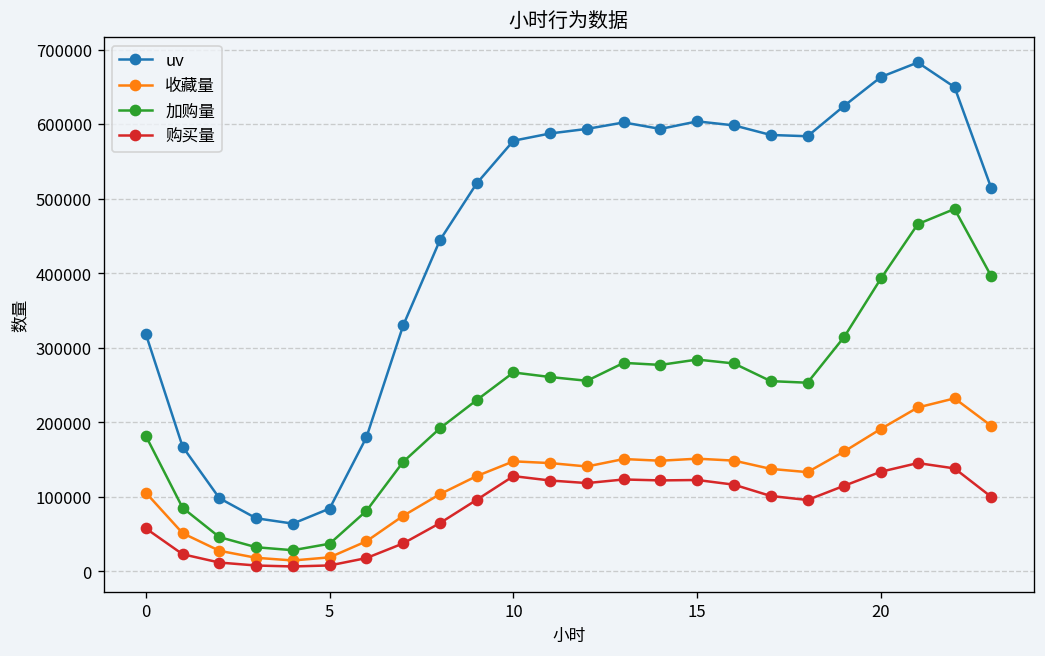

In [61]:
for col, label in zip(
    [ 'users', 'fav_cnt','cart_cnt','buy_cnt'],
    [ 'uv', '收藏量','加购量','购买量']):
    plt.plot(df_gp_hour['hour'], df_gp_hour[col], label=label,marker='o' )
ini_plt_style('小时','数量','小时行为数据')

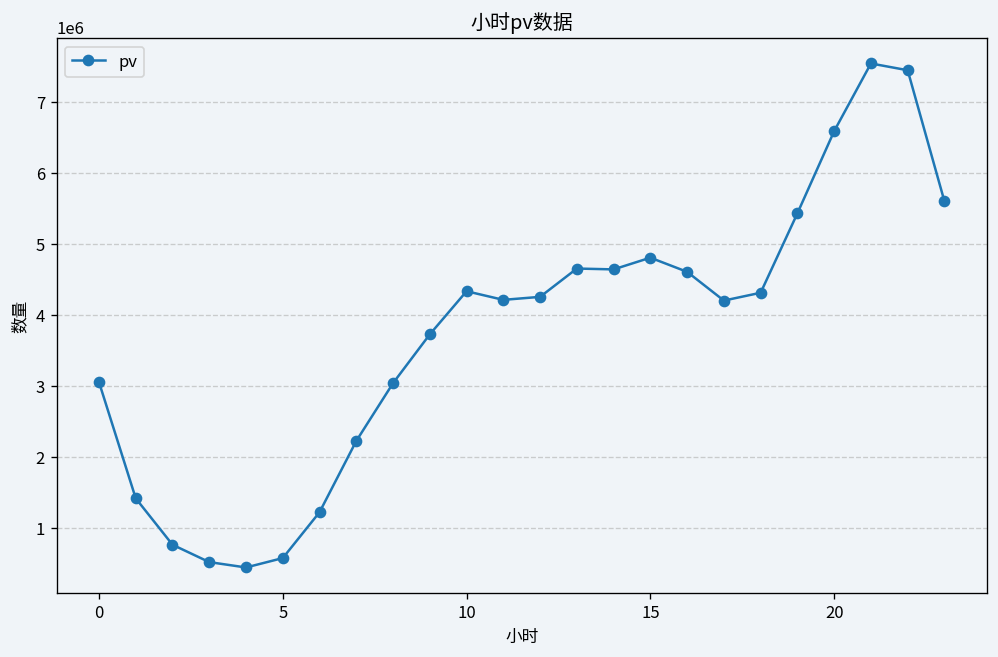

In [62]:
plt.plot(df_gp_hour['hour'], df_gp_hour['pv_cnt'], label='pv',marker='o' )
ini_plt_style('小时','数量','小时pv数据')

小结：
- 很明显，小时行为和pv数据均有一致的走向，与人的作息相符合。
- 从18点开始，用户行为显著增加，这种趋势一直持续到23点，可以定义18~23点为每日的高峰期。
- 加购量在高峰期的增长速度远大于uv、收藏量、购买量。

建议：
- 用户活跃的高峰期在18~23点，应匹配此时活跃人群的用户画像，在相应时间段做更精准的推送、营销。
- 高峰期人们的加购欲望增加，加购的推广活动应该多放在此时。

## RFM模型分析

In [63]:
df_last_buy = conn.execute("""
    SELECT 
        uid, 
        MAX(date) AS last_buy_date
    FROM taobao_behavior
    WHERE behavior = 3
    GROUP BY uid;
    """).fetchdf()

In [64]:
df_buy_cnt = conn.execute("""
    SELECT 
        uid, 
        SUM(behavior = 3) AS buy_cnt
    FROM taobao_behavior
    GROUP BY uid
    HAVING SUM(behavior = 3) >0
    """).fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [65]:
df_RFM = df_last_buy.merge(df_buy_cnt, on='uid',how='inner').sort_values('buy_cnt', ascending=False)

In [66]:
df_RFM[['last_buy_date','buy_cnt']].describe()

,last_buy_date,buy_cnt
count,672404,672404.00000
mean,2017-11-30 10:36:11.123312,2.99791
min,2017-11-25 00:00:00,1.00000
25%,2017-11-29 00:00:00,1.00000
50%,2017-12-01 00:00:00,2.00000
75%,2017-12-03 00:00:00,4.00000
max,2017-12-03 00:00:00,262.00000
std,NaN,2.89428


取平均数作为RFM模型的分类标准

In [67]:
df_RFM['recency'] = df_RFM['last_buy_date'] > df_RFM['last_buy_date'].mean()
df_RFM['frequency'] = df_RFM['buy_cnt'] > df_RFM['buy_cnt'].mean()


In [68]:
def RFM_classification(recency,frequency):
    if recency and frequency:
        return '重要价值客户'
    elif recency and not frequency:
        return '重要深耕客户'
    elif not recency and frequency:
        return '重要唤回客户'
    elif not recency and not frequency:
        return '一般发展客户'
    else:
        return '未分类'
    

In [69]:
df_RFM['RFM'] = df_RFM.apply(lambda x : RFM_classification(x['recency'],x['frequency']),axis = 1)

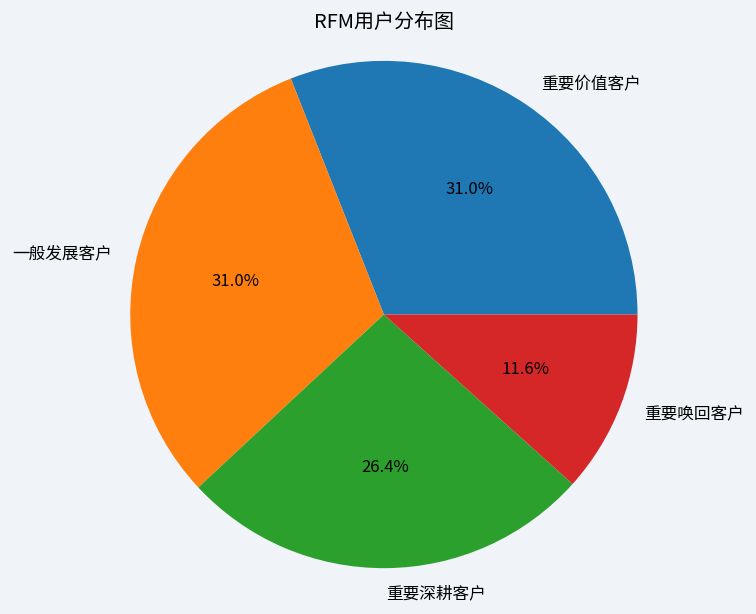

In [70]:
rfm_counts = df_RFM['RFM'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(
    rfm_counts, 
    labels=rfm_counts.index,         
    autopct='%1.1f%%',               
)

plt.title('RFM用户分布图')
plt.axis('equal')  # 保持饼图为圆形
plt.show()

小结：
- 因没有商品价格数据，此处RFM模型只分析前两个维度。
- 重要价值客户，指购买频率高且最近有过购买行为的客户，将这部分用户的体验放在最高优先级，提升其留存率，给予促销等福利发放，活动推广push时要注意避免降低用户体验。
- 重要深耕客户，指购买频率不高但最近有过购买行为的客户，说明客户的购买习惯尚未培养，但有很好的消费潜力，可以着重分析该客户群体的需求、兴趣，刺激消费。
- 重要唤回客户，指购买频率高但最近没有购买行为的客户，说明客户曾经有购买习惯，但是有各种原因最近没有消费，可以给这类用户发推送，送补贴，让他们重新回到消费群体。
- 一般发展客户，指购买频率不高且最近没有购买行为的客户，此类客户的占比较大，应当对他们经常性推送促销信息，适当给予补贴。

## 推荐系统

考虑按照商品大类推荐。由于用户平均购买商品数量只有2.04，购买行为稀疏，无法采用协同过滤的方法，现选用商品大类的热门度+类别共现的推荐方法。

In [71]:
df_user_buy_cat = conn.execute("""
    SELECT 
        uid, 
        cat_id
    FROM taobao_behavior
    WHERE behavior = 3
    """).fetchdf()

In [72]:
top_cats  = df_user_buy_cat['cat_id'].value_counts().head(20)
print("最受欢迎的商品大类：", top_cats)


最受欢迎的商品大类： cat_id
1464116    34589
2735466    33730
2885642    31844
4145813    31658
4756105    28258
4801426    26495
982926     24823
2640118    18332
4159072    18016
1320293    17137
3002561    16472
4357323    15854
4789432    15696
903809     15447
4217906    14442
1299190    13723
570735     13711
2465336    13350
1879194    12868
3607361    12721
Name: count, dtype: int64


In [73]:
# 每个用户的购买大类集合
user_cat = df_user_buy_cat.groupby('uid')['cat_id'].apply(set)

# 构建大类共现次数
co_occurrence = defaultdict(lambda: defaultdict(int))

for cats in user_cat:
    cats = list(cats)
    for i in range(len(cats)):
        for j in range(len(cats)):
            if i != j:
                co_occurrence[cats[i]][cats[j]] += 1

In [74]:
def recommend_for_user(uid, topn=5):
    if uid not in user_cat:
        # 冷启动用户推荐热门大类
        return list(top_cats.index[:topn])
    
    user_cats = user_cat[uid]
    scores = defaultdict(int)

    for cat in user_cats:
        related = co_occurrence.get(cat, {})
        for related_cat, count in related.items():
            if related_cat not in user_cats:
                scores[related_cat] += count  # 共现次数作为分数

    # 推荐得分最高的前 topn 个未买过大类
    recs = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:topn]
    return [cat for cat, score in recs]

# 示例
print("为用户 152127 推荐的商品大类：", recommend_for_user(152127))

为用户 152127 推荐的商品大类： [1464116, 2735466, 2885642, 4145813, 4756105]


## 总结


- 该数据集主要记录了2017年11月25日至2017年12月3日的用户行为数据，行为总数约为1亿条，总用户数98.8万，商品总数量416万，商品大类数量9437。期间产生的总浏览量8996万，总销售量201.6万。
- 往期的收藏加购对于当期的购买数据有较大的助推作用，其贡献的购买量与当期浏览贡献的购买量相当；当期的收藏加购对当期的购买量效用不大。应当注重平时的收藏加购和购物节时的推送曝光活动，让用户养成”平日随意浏览，偶尔加购收藏；购物节时针对需求，精准搜索“的购物习惯。
- 用户的活跃时间段为18点至23点，注意这段黄金时间的曝光，可以将直播活动安排在晚间时段。
- 前10%商品可以选部分作为平台主推，进一步扩大爆品的渗透人群。
- 前10%的商品占据了90%左右的销量，目前平台的商品同质化竞争严重，不利于商家和平台的良性发展，需要深耕个性化消费需求和小品类细分。
- 购物节期间的浏览量增加了30%，但直接由浏览量转化的购买量仅有1.1%，，说明人们在购物节期间有更多的比选负担，需要看比平时更多的页面才能下单。应当注重商品比较功能的开发（如”找相似“功能）。
- 对于RFM模型分类的不同客户，应当采取不同的营销手段，做到精准营销。
- 最后制作了一个基于共现次数的商品大类推荐功能，针对不同的用户，可以根据其历史购买情况，推荐与其购买大类共现次数较高的大类。